# OceanScan - Noise Filtering

Side-scan sonar images carry **speckle**, salt-and-pepper and Gaussian noise. This notebook builds a reusable `preprocess_for_model` function that cleans an image so it is **model-ready**:

1. **Median filter** - removes speckle / salt-and-pepper noise (sonar-typical)
2. **Bilateral filter** - edge-preserving smoothing (keeps target edges sharp)
3. **Light CLAHE** - gentle local contrast (clip 1.2, 16x16 tiles) so flat areas are not over-amplified

> Note: a full-range global stretch is *off by default*. These (synthetic) images are already fairly clean, so aggressive stretching only re-amplifies faint seabed texture into visible grain. Use `stretch=True` only for genuinely dark/noisy imagery.

The same function is used at **prediction time**: a new image is noise-filtered *first*, then passed to the trained model.

It also batch-processes the whole `dataset/` folder into **`output/noise_filter/train_noise_filter/`** (`train` + `val`), copying YOLO labels unchanged (bounding-boxes are normalized, so they stay valid after denoising/resizing).

## 1. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import shutil
from tqdm import tqdm

## 2. The noise-filtering function

`filter_noise(image, ...)` - pure filtering (Median -> Bilateral -> light CLAHE)

`preprocess_for_model(image, ...)` - the **prediction-time** entry point: loads, filters, resizes to `(target_h, target_w)` and returns a clean uint8 3-channel (BGR) image ready for the model. Pass `as_float=True` to get a `float32` array in `[0, 1]`.

In [2]:
def filter_noise(
    image,
    median_ksize=5,          # odd int, kernel for median blur (speckle removal)
    bilateral_d=9,           # bilateral filter diameter
    sigma_color=50,          # gray-level sigma (color similarity)
    sigma_space=50,          # spatial sigma
    enable_clahe=True,       # light local contrast enhancement
    clahe_clip=1.2,          # lower clip = gentler contrast (noise-safe)
    clahe_tile=(16, 16),     # larger tiles = broader context, less texture boosting
    stretch=False,           # optional global stretch to [0,255] (off by default)
    stretch_percentile=1.0,  # pixels clipped at each end when stretch=True
    to_float=False,          # True -> return float32 in [0,1]
):
    """Clean a side-scan sonar image: Median -> Bilateral -> light CLAHE.

    Accepts an ndarray (BGR or grayscale) and returns a uint8 BGR 3-channel
    image with the same spatial shape, or float32 [0,1] if to_float=True.
    """
    if isinstance(image, (str, Path)):
        image = cv2.imread(str(image), cv2.IMREAD_UNCHANGED)
        if image is None:
            raise ValueError(f"Could not read image: {image}")

    # Normalize to a single BGR 3-channel array
    if image.ndim == 2:
        bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    elif image.ndim == 3 and image.shape[2] == 4:
        bgr = cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
    else:
        bgr = np.ascontiguousarray(image)

    # Sonar is effectively grayscale: denoise on a single channel (faster + stable)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # 1) Median blur - kills speckle / salt-and-pepper
    denoised = cv2.medianBlur(gray, median_ksize)

    # 2) Bilateral filter - smooths remaining Gaussian noise, preserves edges
    denoised = cv2.bilateralFilter(
        denoised, bilateral_d, sigma_color, sigma_space
    )

    # 3) Light CLAHE - gentle local contrast (default on, low clip / big tiles)
    if enable_clahe:
        clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
        denoised = clahe.apply(denoised)

    # 4) Optional global stretch to [0,255] - off by default to keep range natural
    if stretch:
        lo = np.percentile(denoised, stretch_percentile)
        hi = np.percentile(denoised, 100 - stretch_percentile)
        denoised = np.clip(
            (denoised.astype(np.float32) - lo) * (255.0 / max(hi - lo, 1)),
            0, 255,
        ).astype(np.uint8)

    out = cv2.merge([denoised] * 3)  # back to BGR 3-channel (model input)
    if to_float:
        return out.astype(np.float32) / 255.0
    return out


def preprocess_for_model(
    image,
    target_w=1024,
    target_h=1024,
    as_float=False,
    **filter_kwargs,
):
    """Prediction-time preprocessing: noise-filter, then resize to model input size.

    Returns a clean uint8 BGR 3-channel image of shape (target_h, target_w, 3),
    or a float32 [0,1] array when as_float=True.
    """
    cleaned = filter_noise(image, to_float=False, **filter_kwargs)
    cleaned = cv2.resize(
        cleaned, (target_w, target_h), interpolation=cv2.INTER_AREA
    )
    if as_float:
        return cleaned.astype(np.float32) / 255.0
    return cleaned

## 3. Test on a sample - before / after

Sample       : bal2_00000.png
Input shape  : (664, 664, 3) uint8
Output shape : (1024, 1024, 3) uint8
Output range : [2, 244]


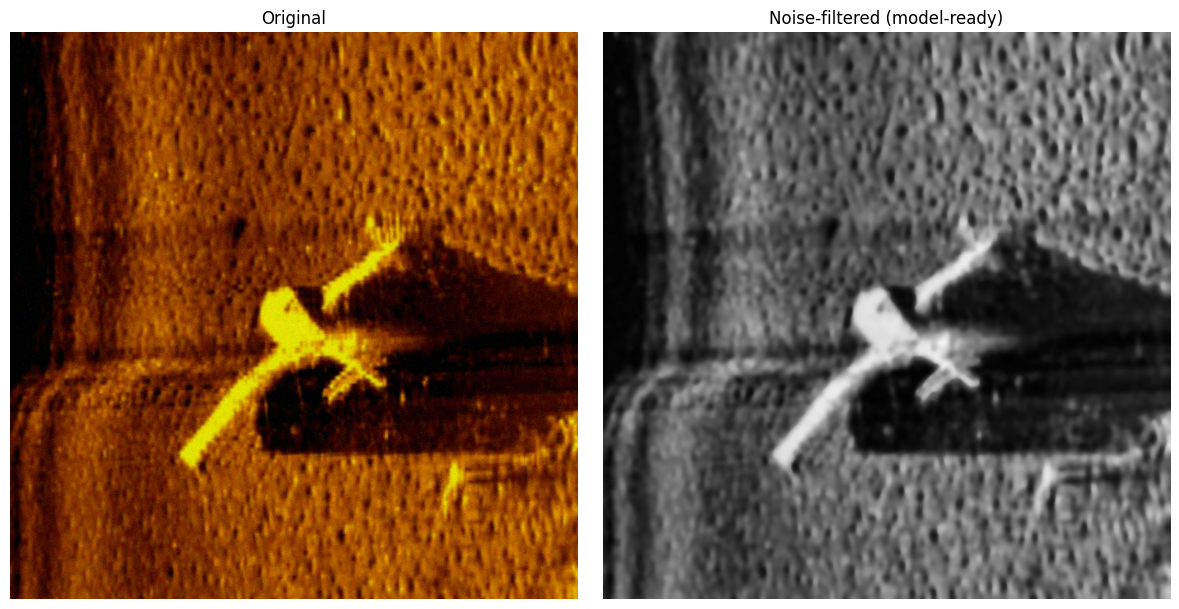

In [3]:
ROOT = Path(r"D:\1. Project Program\1.SIH\OceanScan")
SRC = ROOT / "dataset"
DST = ROOT / "output" / "noise_filter" / "train_noise_filter"
SUBSETS = ["train", "val"]

sample = next((SRC / "train" / "images").glob("*"))
img = cv2.imread(str(sample))
cleaned = preprocess_for_model(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, title, im in zip(axes, ["Original", "Noise-filtered (model-ready)"],
                         [img, cleaned]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
print("Sample       :", sample.name)
print("Input shape  :", img.shape, img.dtype)
print("Output shape :", cleaned.shape, cleaned.dtype)
print("Output range : [%d, %d]" % (cleaned.min(), cleaned.max()))
plt.tight_layout()
plt.show()

## 4. Labels stay valid

YOLO labels are normalized and unaffected by denoising or resize. We verify every image has its matching label file.

In [4]:
missing = []
for subset in SUBSETS:
    img_dir = SRC / subset / "images"
    lbl_dir = SRC / subset / "labels"
    for img_p in sorted(img_dir.iterdir()):
        lbl_p = lbl_dir / img_p.with_suffix(".txt").name
        if not lbl_p.exists():
            missing.append(str(lbl_p))

print(f"Missing label files: {len(missing)}")
if missing:
    print(*missing[:10], sep="\n")

Missing label files: 0


## 5. Batch-process the full dataset -> `output/noise_filter/train_noise_filter/`

In [5]:
def process_dataset(src, dst, subsets=None, overwrite=False):
    """Filter all images in src into dst, preserving the images/ labels/ layout.
    YOLO label .txt files are copied unchanged (normalized coords stay valid).
    """
    src = Path(src)
    dst = Path(dst)
    subsets = subsets or [d.name for d in src.iterdir() if d.is_dir()]
    processed, skipped = 0, 0

    for subset in subsets:
        in_img = src / subset / "images"
        in_lbl = src / subset / "labels"
        out_img = dst / subset / "images"
        out_lbl = dst / subset / "labels"
        out_img.mkdir(parents=True, exist_ok=True)
        out_lbl.mkdir(parents=True, exist_ok=True)

        files = sorted(in_img.glob("*.png")) + sorted(in_img.glob("*.jpg"))
        for img_p in tqdm(files, desc=subset):
            out_p = out_img / img_p.name
            if out_p.exists() and not overwrite:
                skipped += 1
                continue
            img = cv2.imread(str(img_p))
            cleaned = preprocess_for_model(img)
            if not cv2.imwrite(str(out_p), cleaned):
                raise IOError(f"Failed to write {out_p}")
            processed += 1

        for lbl_p in in_lbl.glob("*.txt"):
            shutil.copy2(str(lbl_p), str(out_lbl / lbl_p.name))

    print(f"Processed: {processed} | Skipped (exists): {skipped}")
    return processed, skipped


processed, skipped = process_dataset(SRC, DST, subsets=SUBSETS)
print(f"Output root: {DST}")

train:   0%|          | 0/9600 [00:00<?, ?it/s]

train:   0%|          | 2/9600 [00:00<13:26, 11.91it/s]

train:   0%|          | 4/9600 [00:00<12:18, 12.99it/s]

train:   0%|          | 6/9600 [00:00<13:21, 11.97it/s]

train:   0%|          | 8/9600 [00:00<12:27, 12.83it/s]

...

val: 100%|█████████▉| 980/984 [01:11<00:00, 15.25it/s]

val: 100%|█████████▉| 982/984 [01:11<00:00, 15.80it/s]

val: 100%|██████████| 984/984 [01:12<00:00, 16.49it/s]

val: 100%|██████████| 984/984 [01:12<00:00, 13.66it/s]

Processed: 10584 | Skipped (exists): 0
Output root: D:\1. Project Program\1.SIH\OceanScan\output\noise_filter\train_noise_filter


## 6. Verify output

In [6]:
rows = []
for subset in SUBSETS:
    imgs = list((DST / subset / "images").glob("*"))
    lbls = list((DST / subset / "labels").glob("*.txt"))
    rows.append({"subset": subset, "images": len(imgs), "labels": len(lbls)})

report = pd.DataFrame(rows)
report["total_size_MB"] = report["subset"].apply(
    lambda s: round(
        sum(f.stat().st_size for f in (DST / s).rglob("*") if f.is_file()) / 1e6, 1
    )
)
print(report.to_string(index=False))

subset  images  labels  total_size_MB
 train    9600    9600         8664.7
   val     984     984          991.8


## 7. Prediction-time usage (for your model)

When you have the trained model, load it, then pass each incoming image through `preprocess_for_model` **before** inference:

```python
model_input = preprocess_for_model("path/to/new_image.png", target_w=1024, target_h=1024, as_float=True)
pred = model.predict(model_input)
```

In [7]:
# Demo: single image on the fly (same path the model will use)
demo = preprocess_for_model(
    next((SRC / "val" / "images").glob("*")),
    as_float=True,
)
print("Model-ready input:", demo.shape, demo.dtype, "| range:", demo.min(), demo.max())

Model-ready input: (1024, 1024, 3) float32 | range: 0.003921569 0.9843137
